Hola **Victor**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas.

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b>  Muchas gracias, Patricio, por las observaciones y recomendaciones realizadas. Fueron de gran ayuda para identificar los puntos que debía mejorar y complementar, y me permitieron darle un mejor cierre al proyecto.

Agradezco mucho el acompañamiento y la retroalimentación durante esta última etapa

<div class="alert alert-block alert-info">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Hola Victor, me alegro mucho que con las recomendaciones pudiste pulir más el excelente trabajo que ya venías haciendo. Recuerda que siempre el comunicar de manera sencilla resultados que pueden ser complejos es un skill vital para un profesional de datos.
</div>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# cargar archivos
orders =  pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [ ]:
# explorar datasets
display(orders.head())

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [ ]:
display(catalog.head())

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
display(marketing.head())

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
# Dimensiones de los datasets
print('Dimensiones de orders:', orders.shape)
print('Dimensiones de catalog:', catalog.shape)
print('Dimensiones de marketing:', marketing.shape)

Dimensiones de orders: (25100, 12)
Dimensiones de catalog: (7, 4)
Dimensiones de marketing: (1620, 5)


In [ ]:
# Información general de cada dataset
print('Información de orders:')
orders.info()

print('\nInformación de catalog:')
catalog.info()

print('\nInformación de marketing:')
marketing.info()

Información de orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

Información de catalog:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# tu código aquí
# Convertir las columnas de fecha al tipo datetime
orders['fecha_hora_pedido'] = pd.to_datetime(
    orders['fecha_hora_pedido'],
    errors='coerce'
)

marketing['fecha'] = pd.to_datetime(
    marketing['fecha'],
    errors='coerce'
)

In [ ]:
# Verificar tipos de datos y posibles fechas inválidas
print('Tipo de fecha_hora_pedido:', orders['fecha_hora_pedido'].dtype)
print('Fechas inválidas en orders:', orders['fecha_hora_pedido'].isna().sum())

print('\nTipo de fecha:', marketing['fecha'].dtype)
print('Fechas inválidas en marketing:', marketing['fecha'].isna().sum())

Tipo de fecha_hora_pedido: datetime64[ns]
Fechas inválidas en orders: 0

Tipo de fecha: datetime64[ns]
Fechas inválidas en marketing: 0


In [ ]:
# Resumen estadístico de las variables numéricas
display(orders.describe())
display(catalog.describe())
display(marketing.describe())

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [ ]:
# Revisar pedidos con cantidades negativas o extremadamente altas
orders[
    (orders['cantidad'] < 0) |
    (orders['cantidad'] > 100)
].sort_values('cantidad')

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.00
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.00
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.00
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.00
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.00
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.00


In [ ]:
# Contar cantidades negativas, iguales a cero y mayores a 100
print('Cantidades negativas:', (orders['cantidad'] < 0).sum())
print('Cantidades iguales a cero:', (orders['cantidad'] == 0).sum())
print('Cantidades mayores a 100:', (orders['cantidad'] > 100).sum())

Cantidades negativas: 4
Cantidades iguales a cero: 0
Cantidades mayores a 100: 10


In [ ]:
# Mostrar los pedidos con cantidades negativas o mayores a 100
display(
    orders[
        (orders['cantidad'] < 0) |
        (orders['cantidad'] > 100)
    ].sort_values('cantidad')
)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.00
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.00
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.00
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.00
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.00
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.00


In [ ]:
# Calcular la proporción de pedidos con cantidades anómalas
pedidos_anomalos = (
    (orders['cantidad'] < 0) |
    (orders['cantidad'] > 100)
)

print('Registros anómalos:', pedidos_anomalos.sum())
print(
    'Porcentaje del dataset:',
    round(pedidos_anomalos.mean() * 100, 2),
    '%'
)

Registros anómalos: 14
Porcentaje del dataset: 0.06 %


In [ ]:
# Obtener los índices y eliminar los registros anómalos
indices_anomalos = orders[pedidos_anomalos].index
orders = orders.drop(index=indices_anomalos).copy()

# Verificar el resultado
print('Cantidad mínima:', orders['cantidad'].min())
print('Cantidad máxima:', orders['cantidad'].max())
print('Dimensiones después de la limpieza:', orders.shape)

Cantidad mínima: 1.0
Cantidad máxima: 2.0
Dimensiones después de la limpieza: (25086, 12)


**Tratamiento de cantidades anómalas**: Se identificaron 14 registros inconsistentes: 4 pedidos con cantidades negativas y 10 con cantidades extremadamente altas (10.000 o 20.000 unidades). Debido a que no existe información que permita determinar sus valores correctos y representan aproximadamente el 0,06 % del dataset, se eliminaron para evitar distorsiones en el análisis. Después de la limpieza, la variable cantidad presenta valores válidos entre 1 y 2 unidades.

In [ ]:

# Revisar valores ausentes en todas las columnas
orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

In [ ]:

# Calcular el monto total esperado
orders['monto_esperado'] = (
    orders['cantidad'] * orders['precio_unitario']
    - orders['monto_descuento']
)

# Calcular la diferencia entre el monto registrado y el esperado
orders['diferencia_monto'] = (
    orders['monto_total'] - orders['monto_esperado']
).round(2)

# Contar montos inconsistentes
print(
    'Montos inconsistentes:',
    (orders['diferencia_monto'].abs() > 0.01).sum()
)

Montos inconsistentes: 0


**Consistencia de los montos**: Se calculó el monto esperado a partir de la cantidad, el precio unitario y el descuento. No se encontraron diferencias superiores a un centavo entre el monto calculado y el registrado, por lo que los montos se consideran consistentes

In [ ]:
# Eliminar columnas auxiliares
orders = orders.drop(
    columns=['monto_esperado', 'diferencia_monto']
)

In [ ]:
# Contar registros duplicados en cada dataset
print('Duplicados en orders:', orders.duplicated().sum())
print('Duplicados en catalog:', catalog.duplicated().sum())
print('Duplicados en marketing:', marketing.duplicated().sum())

Duplicados en orders: 100
Duplicados en catalog: 0
Duplicados en marketing: 0


In [ ]:
# Mostrar los registros duplicados de orders
orders[orders.duplicated(keep=False)].sort_values(
    by=list(orders.columns)
).head(10)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
10829,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08
25065,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08
10856,order_10856,user_1899,2025-03-18,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,1.0,72.53,0.0,72.53
25044,order_10856,user_1899,2025-03-18,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,1.0,72.53,0.0,72.53
11449,order_11449,user_1480,2025-03-21,Mexico,desktop,paid_search,Vacuum-Pro-Black,Hogar,1.0,60.55,5.0,55.55
25083,order_11449,user_1480,2025-03-21,Mexico,desktop,paid_search,Vacuum-Pro-Black,Hogar,1.0,60.55,5.0,55.55


In [ ]:
# Eliminar duplicados exactos
orders = orders.drop_duplicates().copy()

# Verificar el resultado
print('Duplicados restantes:', orders.duplicated().sum())
print('Dimensiones finales:', orders.shape)

Duplicados restantes: 0
Dimensiones finales: (24986, 12)


**Tratamiento de registros duplicados**: Se identificaron 100 registros duplicados exactos en orders. Se eliminaron las copias conservando la primera aparición de cada registro. Después de la limpieza, el dataset quedó con 24.986 filas y no presenta duplicados exactos. En catalog y marketing no se encontraron registros duplicados

In [ ]:
#Revisar todas las columnas de tipo object#
for columna in orders.select_dtypes(include='object').columns:
    print(f'\nColumna: {columna}')
    print(orders[columna].value_counts(dropna=False))


Columna: id_pedido
order_1638     1
order_22111    1
order_656      1
order_4740     1
order_3932     1
              ..
order_18639    1
order_6939     1
order_23465    1
order_23964    1
order_16609    1
Name: id_pedido, Length: 24986, dtype: int64

Columna: id_usuario
user_7769    11
user_7975    10
user_5748    10
user_3000    10
user_4065    10
             ..
user_1605     1
user_6867     1
user_4534     1
user_598      1
user_7275     1
Name: id_usuario, Length: 7642, dtype: int64

Columna: pais
Colombia     7479
Mexico       7474
Argentina    7256
mexico        862
colombia      823
argentina     796
NaN           296
Name: pais, dtype: int64

Columna: dispositivo
desktop    12702
mobile     12264
NaN           20
Name: dispositivo, dtype: int64

Columna: fuente_referencia
social         8398
organic        8285
paid_search    8273
NaN              30
Name: fuente_referencia, dtype: int64

Columna: nombre_producto
Blender-XL-Red          4179
Jacket-Winter-M         4176
Vacuu

In [ ]:
# Estandarizar los nombres de los países
orders['pais'] = orders['pais'].str.capitalize()

# Verificar las categorías después de la corrección
orders['pais'].value_counts(dropna=False)

Mexico       8336
Colombia     8302
Argentina    8052
NaN           296
Name: pais, dtype: int64

**Consistencia de las variables categóricas**: Se revisaron las columnas de tipo texto y se detectaron diferencias en el uso de mayúsculas y minúsculas en la variable pais. Los nombres se estandarizaron con la primera letra en mayúscula. Las demás variables categóricas no presentaron inconsistencias de escritura. Los valores ausentes se tratarán posteriormente

In [ ]:
# Revisar las columnas categóricas de catalog
print('CATEGORÍAS DE CATALOG')

for columna in catalog.select_dtypes(include='object').columns:
    print(f'\nColumna: {columna}')
    print(catalog[columna].value_counts(dropna=False))


# Revisar las columnas categóricas de marketing
print('\nCATEGORÍAS DE MARKETING')

for columna in marketing.select_dtypes(include='object').columns:
    print(f'\nColumna: {columna}')
    print(marketing[columna].value_counts(dropna=False))


CATEGORÍAS DE CATALOG

Columna: nombre_producto
Blender-XL-Red          1
Sneakers-Urban-42       1
Jacket-Winter-M         1
Vacuum-Pro-Black        1
Phone-Pro-128GB         1
Tablet-Standard-64GB    1
Laptop-Gaming-16GB      1
Name: nombre_producto, dtype: int64

Columna: categoria_producto
Electrónica    3
Moda           2
Hogar          2
Name: categoria_producto, dtype: int64

Columna: proveedor
Fuller, Pena and Myers     1
Bowers LLC                 1
King Ltd                   1
Rivera, Carr and Finley    1
Long-Reid                  1
Greene-Smith               1
Mcmillan-Rhodes            1
Name: proveedor, dtype: int64

CATEGORÍAS DE MARKETING

Columna: pais
Argentina    540
Mexico       540
Colombia     540
Name: pais, dtype: int64

Columna: id_campaña
paid_search_Mexico       180
social_Mexico            180
organic_Colombia         180
organic_Argentina        180
organic_Mexico           180
paid_search_Colombia     180
paid_search_Argentina    180
social_Colombia       

In [ ]:
# Contar cuántos países diferentes tiene cada usuario
paises_por_usuario = (
    orders
    .dropna(subset=['pais'])
    .groupby('id_usuario')['pais']
    .nunique()
)

print(paises_por_usuario.value_counts())

1    7624
Name: pais, dtype: int64


In [ ]:
# Obtener para cada fila el país conocido del mismo usuario
pais_por_usuario = (
    orders
    .groupby('id_usuario')['pais']
    .transform('first')
)

# Ver cuántos países ausentes se pueden recuperar
recuperables_pais = (
    orders['pais'].isna() & pais_por_usuario.notna()
).sum()

print('Países ausentes:', orders['pais'].isna().sum())
print('Países recuperables:', recuperables_pais)

Países ausentes: 296
Países recuperables: 277


In [ ]:
# Completar los países recuperables con el país conocido del mismo usuario
orders['pais'] = orders['pais'].fillna(pais_por_usuario)

# Verificar el resultado
print('Países ausentes restantes:', orders['pais'].isna().sum())

Países ausentes restantes: 19


In [ ]:
# Contar cuántos dispositivos diferentes tiene cada usuario
dispositivos_por_usuario = (
    orders
    .dropna(subset=['dispositivo'])
    .groupby('id_usuario')['dispositivo']
    .nunique()
)

# Mostrar la cantidad de usuarios según su número de dispositivos
print(dispositivos_por_usuario.value_counts())

1    7640
Name: dispositivo, dtype: int64


In [ ]:
# Obtener para cada fila el dispositivo conocido del mismo usuario
dispositivo_por_usuario = (
    orders
    .groupby('id_usuario')['dispositivo']
    .transform('first')
)

# Contar cuántos dispositivos ausentes se pueden recuperar
recuperables_dispositivo = (
    orders['dispositivo'].isna() & dispositivo_por_usuario.notna()
).sum()

print('Dispositivos ausentes:', orders['dispositivo'].isna().sum())
print('Dispositivos recuperables:', recuperables_dispositivo)

Dispositivos ausentes: 20
Dispositivos recuperables: 18


In [ ]:
# Completar los dispositivos con el dato conocido del mismo usuario
orders['dispositivo'] = orders['dispositivo'].fillna(
    dispositivo_por_usuario
)

# Verificar los valores ausentes restantes
print(
    'Dispositivos ausentes restantes:',
    orders['dispositivo'].isna().sum()
)

Dispositivos ausentes restantes: 2


In [ ]:
# Revisar valores ausentes y distribución de fuente_referencia
print(
    'Fuentes de referencia ausentes:',
    orders['fuente_referencia'].isna().sum()
)

print(
    orders['fuente_referencia'].value_counts(
        dropna=False,
        normalize=True
    ).round(4) * 100
)

Fuentes de referencia ausentes: 30
social         33.61
organic        33.16
paid_search    33.11
NaN             0.12
Name: fuente_referencia, dtype: float64


In [ ]:
# Reemplazar las fuentes ausentes por una categoría informativa
orders['fuente_referencia'] = (
    orders['fuente_referencia'].fillna('Sin información')
)

# Verificar el resultado
print(
    orders['fuente_referencia'].value_counts(dropna=False)
)

social             8398
organic            8285
paid_search        8273
Sin información      30
Name: fuente_referencia, dtype: int64


In [ ]:
display(orders[
    orders['nombre_producto'].isna()
    | orders['categoria_producto'].isna()
].head(10))

display(catalog.head())

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
44,order_44,user_2899,2025-02-22,Colombia,desktop,Sin información,NaN,NaN,1.0,318.38,5.0,313.38
45,order_45,user_6196,2025-02-10,Mexico,mobile,Sin información,NaN,NaN,2.0,354.06,10.0,698.12
46,order_46,user_5815,2025-04-24,Mexico,mobile,Sin información,NaN,NaN,1.0,359.31,10.0,349.31
47,order_47,user_406,2025-05-08,Colombia,mobile,Sin información,NaN,NaN,2.0,476.78,0.0,953.56
48,order_48,user_6187,2025-01-26,Colombia,desktop,Sin información,NaN,NaN,2.0,137.96,0.0,275.93
49,order_49,user_7225,2025-04-04,Argentina,desktop,Sin información,NaN,NaN,2.0,433.76,0.0,867.53
50,order_50,user_1840,2025-02-05,Mexico,desktop,Sin información,NaN,NaN,1.0,495.38,5.0,490.38
51,order_51,user_5998,2025-02-21,Mexico,desktop,Sin información,NaN,NaN,2.0,382.94,0.0,765.89
52,order_52,user_5679,2025-04-17,Argentina,mobile,Sin información,NaN,NaN,2.0,415.01,0.0,830.01
53,order_53,user_5936,2025-01-02,Argentina,desktop,Sin información,NaN,NaN,2.0,236.49,0.0,472.98


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [ ]:
# Comparar los valores ausentes de nombre y categoría
faltantes_producto = pd.crosstab(
    orders['nombre_producto'].isna(),
    orders['categoria_producto'].isna(),
    rownames=['Nombre ausente'],
    colnames=['Categoría ausente']
)

display(faltantes_producto)

Categoría ausente,False,True
Nombre ausente,,
False,24906,50
True,0,30


In [ ]:
# Crear un mapa que relacione cada producto con su categoría
mapa_categorias = (
    catalog
    .drop_duplicates(subset='nombre_producto')
    .set_index('nombre_producto')['categoria_producto']
)

# Buscar la categoría correspondiente a cada producto de orders
categoria_desde_catalogo = (
    orders['nombre_producto'].map(mapa_categorias)
)

# Completar únicamente las categorías ausentes
orders['categoria_producto'] = (
    orders['categoria_producto'].fillna(categoria_desde_catalogo)
)

# Verificar los valores ausentes restantes
print(
    'Nombres de producto ausentes:',
    orders['nombre_producto'].isna().sum()
)

print(
    'Categorías de producto ausentes:',
    orders['categoria_producto'].isna().sum()
)

Nombres de producto ausentes: 30
Categorías de producto ausentes: 30


In [ ]:
# Seleccionar las filas sin nombre o categoría de producto
filas_producto_ausente = orders[
    orders['nombre_producto'].isna()
    | orders['categoria_producto'].isna()
]

# Revisar valores ausentes dentro de estas 30 filas
display(filas_producto_ausente.isna().sum())

# Visualizar las primeras filas
display(filas_producto_ausente.head())

id_pedido              0
id_usuario             0
fecha_hora_pedido      0
pais                   0
dispositivo            0
fuente_referencia      0
nombre_producto       30
categoria_producto    30
cantidad               0
precio_unitario        0
monto_descuento        0
monto_total            0
dtype: int64

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
44,order_44,user_2899,2025-02-22,Colombia,desktop,Sin información,NaN,NaN,1.0,318.38,5.0,313.38
45,order_45,user_6196,2025-02-10,Mexico,mobile,Sin información,NaN,NaN,2.0,354.06,10.0,698.12
46,order_46,user_5815,2025-04-24,Mexico,mobile,Sin información,NaN,NaN,1.0,359.31,10.0,349.31
47,order_47,user_406,2025-05-08,Colombia,mobile,Sin información,NaN,NaN,2.0,476.78,0.0,953.56
48,order_48,user_6187,2025-01-26,Colombia,desktop,Sin información,NaN,NaN,2.0,137.96,0.0,275.93


In [ ]:
# Comprobar si las 30 filas sin producto son las mismas
# que tenían la fuente de referencia ausente
coincidencias = (
    orders['nombre_producto'].isna()
    & orders['categoria_producto'].isna()
    & (orders['fuente_referencia'] == 'Sin información')
).sum()

print('Filas con los tres datos sin información:', coincidencias)

Filas con los tres datos sin información: 30


In [ ]:
# Clasificar los productos y categorías que no pudieron recuperarse
orders['nombre_producto'] = (
    orders['nombre_producto'].fillna('Producto desconocido')
)

orders['categoria_producto'] = (
    orders['categoria_producto'].fillna('Sin información')
)

# Verificar los valores ausentes
print(orders.isna().sum())

id_pedido              0
id_usuario             0
fecha_hora_pedido      0
pais                  19
dispositivo            2
fuente_referencia      0
nombre_producto        0
categoria_producto     0
cantidad              50
precio_unitario       50
monto_descuento       50
monto_total            0
dtype: int64


**Tratamiento de valores ausentes en variables categóricas**

Se analizaron los valores ausentes de las variables categóricas antes de realizar cualquier eliminación o imputación.

- **País:** se comprobó que cada usuario con información disponible estaba asociado con un único país. Esto permitió recuperar 277 de los 296 valores ausentes utilizando otros pedidos del mismo usuario. Permanecieron 19 casos sin información.
- **Dispositivo:** se verificó que cada usuario con información conocida estaba asociado con un solo tipo de dispositivo. Se recuperaron 18 de los 20 valores ausentes y quedaron 2 casos pendientes.
- **Fuente de referencia:** los 30 valores ausentes se clasificaron como `Sin información`, ya que esta variable puede cambiar entre pedidos y no era posible inferirla de manera confiable.
- **Categoría del producto:** se recuperaron 50 categorías mediante la correspondencia entre `nombre_producto` y el catálogo.
- **Producto y categoría:** se identificaron 30 registros sin información simultánea en `fuente_referencia`, `nombre_producto` y `categoria_producto`. Este patrón sugiere un posible problema sistemático de captura o integración. Como los demás campos de estas ventas estaban completos, los registros se conservaron y se clasificaron como `Producto desconocido` y `Sin información`.

Después de este tratamiento, permanecen pendientes 19 valores ausentes en `pais` y 2 en `dispositivo`. Estos casos se revisarán junto con el resto de la información de sus registros antes de definir su tratamiento final.

In [ ]:
# Seleccionar filas con al menos un valor numérico ausente
filas_numericas_ausentes = orders[
    orders[
        ['cantidad', 'precio_unitario', 'monto_descuento']
    ].isna().any(axis=1)
]

# Revisar las combinaciones de valores ausentes
faltantes_numericos = (
    filas_numericas_ausentes[
        ['cantidad', 'precio_unitario', 'monto_descuento']
    ]
    .isna()
    .value_counts()
)

display(faltantes_numericos)

# Observar la información disponible en esas filas
display(filas_numericas_ausentes.head(10))

cantidad  precio_unitario  monto_descuento
True      True             True               50
dtype: int64

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,595.85
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,458.15
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,NaN,NaN,NaN,319.75
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,227.55
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,Electrónica,NaN,NaN,NaN,432.39
79,order_79,user_6438,2025-03-22,Colombia,desktop,paid_search,Sneakers-Urban-42,Moda,NaN,NaN,NaN,527.15
80,order_80,user_6790,2025-01-03,Mexico,desktop,organic,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,711.18
81,order_81,user_232,2025-05-16,Mexico,mobile,paid_search,Tablet-Standard-64GB,Electrónica,NaN,NaN,NaN,41.08
82,order_82,user_5665,2025-02-07,Colombia,mobile,paid_search,Sneakers-Urban-42,Moda,NaN,NaN,NaN,431.55
83,order_83,user_5225,2025-04-25,Argentina,mobile,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,279.35


In [ ]:
# Obtener los productos presentes en las 50 filas afectadas
productos_afectados = (
    filas_numericas_ausentes['nombre_producto']
    .dropna()
    .unique()
)

# Consultar esos productos en el catálogo
catalog_productos_afectados = catalog[
    catalog['nombre_producto'].isin(productos_afectados)
]

display(catalog_productos_afectados)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:

# Seleccionar las filas con al menos un valor numérico ausente
filas_numericas_ausentes = orders[
    orders[
        ['cantidad', 'precio_unitario', 'monto_descuento']
    ].isna().any(axis=1)
]

# Calcular la cantidad y el porcentaje de filas afectadas
cantidad_filas_afectadas = len(filas_numericas_ausentes)

porcentaje_filas_afectadas = (
    cantidad_filas_afectadas / len(orders) * 100
)

# Calcular la participación de estas filas en las ventas
monto_filas_afectadas = (
    filas_numericas_ausentes['monto_total'].sum()
)

porcentaje_monto_afectado = (
    monto_filas_afectadas
    / orders['monto_total'].sum()
    * 100
)

# Mostrar los resultados
print('Filas afectadas:', cantidad_filas_afectadas)

print(
    'Porcentaje de filas afectadas:',
    round(porcentaje_filas_afectadas, 2), '%'
)

print(
    'Monto total de las filas afectadas:',
    round(monto_filas_afectadas, 2)
)

print(
    'Participación en el monto total:',
    round(porcentaje_monto_afectado, 2), '%'
)

Filas afectadas: 50
Porcentaje de filas afectadas: 0.2 %
Monto total de las filas afectadas: 21628.0
Participación en el monto total: 0.22 %


In [ ]:
# Calcular los montos
monto_total = orders['monto_total'].sum()
monto_afectado = filas_numericas_ausentes['monto_total'].sum()
monto_sin_afectadas = monto_total - monto_afectado

# Mostrar la comparación
print('Monto total:', monto_total)
print('Monto afectado:', monto_afectado)
print('Monto sin las filas afectadas:', monto_sin_afectadas)

Monto total: 9643909.559999999
Monto afectado: 21628.000000000004
Monto sin las filas afectadas: 9622281.559999999


**Tratamiento de valores ausentes en variables numéricas**

Se identificaron 50 registros con valores ausentes simultáneamente en `cantidad`, `precio_unitario` y `monto_descuento`. Estas observaciones representan el 0,20 % del conjunto de datos y aportan $21.628, equivalentes al 0,22 % del monto total de ventas.

Debido a su baja participación y a que el campo `monto_total` se encuentra completo, no se consideró necesario realizar una reconstrucción compleja de los valores faltantes. Tampoco se aplicaron medidas de imputación como la mediana, ya que estas variables guardan una relación matemática y su reemplazo independiente podría generar inconsistencias.

Por esta razón, los registros se conservaron con sus valores ausentes debidamente identificados. Podrán utilizarse en los análisis generales de ingresos basados en `monto_total`, pero deberán excluirse de los análisis específicos que dependan de `cantidad`, `precio_unitario` o `monto_descuento`.

In [ ]:
# Verificar valores ausentes antes de exportar
print('Valores ausentes en orders:')
display(orders.isna().sum())

print('Valores ausentes en catalog:')
display(catalog.isna().sum())

print('Valores ausentes en marketing:')
display(marketing.isna().sum())

Valores ausentes en orders:


id_pedido              0
id_usuario             0
fecha_hora_pedido      0
pais                  19
dispositivo            2
fuente_referencia      0
nombre_producto        0
categoria_producto     0
cantidad              50
precio_unitario       50
monto_descuento       50
monto_total            0
dtype: int64

Valores ausentes en catalog:


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Valores ausentes en marketing:


fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64

In [ ]:
# Identificar los valores categóricos que no pudieron recuperarse
orders['pais'] = orders['pais'].fillna('Sin información')

orders['dispositivo'] = (
    orders['dispositivo'].fillna('Sin información')
)

# Verificar el resultado
print('Países ausentes:', orders['pais'].isna().sum())
print(
    'Dispositivos ausentes:',
    orders['dispositivo'].isna().sum()
)

Países ausentes: 0
Dispositivos ausentes: 0


In [ ]:
# Revisar cuántos canales conocidos tiene cada campaña
canales_por_campaña = (
    marketing.dropna(subset=['canal'])
    .groupby('id_campaña')['canal']
    .nunique()
)

print(canales_por_campaña.value_counts())

1    9
Name: canal, dtype: int64


In [ ]:
# Crear un mapa entre cada campaña y su canal
mapa_canales = (
    marketing.dropna(subset=['canal'])
    .drop_duplicates(subset=['id_campaña'])
    .set_index('id_campaña')['canal']
)

# Buscar el canal correspondiente a cada campaña
canal_desde_campaña = marketing['id_campaña'].map(mapa_canales)

# Completar únicamente los canales ausentes
marketing['canal'] = (
    marketing['canal'].fillna(canal_desde_campaña)
)

# Verificar el resultado
print(
    'Canales ausentes:',
    marketing['canal'].isna().sum()
)

Canales ausentes: 0


In [ ]:
print('Valores ausentes en orders:')
display(orders.isna().sum())

print('Valores ausentes en catalog:')
display(catalog.isna().sum())

print('Valores ausentes en marketing:')
display(marketing.isna().sum())

Valores ausentes en orders:


id_pedido              0
id_usuario             0
fecha_hora_pedido      0
pais                   0
dispositivo            0
fuente_referencia      0
nombre_producto        0
categoria_producto     0
cantidad              50
precio_unitario       50
monto_descuento       50
monto_total            0
dtype: int64

Valores ausentes en catalog:


nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Valores ausentes en marketing:


fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

In [ ]:
# Estandarizar el nombre de la categoría Electrónica

orders['categoria_producto'] = (
    orders['categoria_producto']
    .replace('Electronica', 'Electrónica')
)

# Verificar el resultado
orders['categoria_producto'].value_counts(
    dropna=False
)

Hogar              8355
Moda               8324
Electrónica        8277
Sin información      30
Name: categoria_producto, dtype: int64

**Validación final de valores ausentes**

Después de aplicar los tratamientos definidos, se realizó una validación final de los valores ausentes en los tres conjuntos de datos.

- **Orders:** las variables categóricas quedaron completas. Permanecen 50 valores ausentes simultáneamente en `cantidad`, `precio_unitario` y `monto_descuento`. Estos registros se conservaron porque representan únicamente el 0,20 % de las observaciones y el 0,22 % del monto total de ventas. Además, el campo `monto_total` está disponible, por lo que todavía pueden utilizarse en los análisis generales de ingresos.
- **Catalog:** no presenta valores ausentes.
- **Marketing:** los 101 valores ausentes de `canal` se recuperaron utilizando la correspondencia con `id_campaña`, después de comprobar que cada campaña estaba asociada con un único canal.

Con esta validación se da por finalizada la etapa de tratamiento de valores ausentes. Los registros incompletos conservados en `orders` deberán excluirse únicamente de aquellos análisis que dependan específicamente de `cantidad`, `precio_unitario` o `monto_descuento`.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

print('Archivos exportados correctamente:')
print('- orders_clean.csv')
print('- catalog_clean.csv')
print('- marketing_clean.csv')

Archivos exportados correctamente:
- orders_clean.csv
- catalog_clean.csv
- marketing_clean.csv


In [ ]:
# Comprobar los archivos exportados

orders_exportado = pd.read_csv('orders_clean.csv')
catalog_exportado = pd.read_csv('catalog_clean.csv')
marketing_exportado = pd.read_csv('marketing_clean.csv')

print('Dimensiones de orders_clean:', orders_exportado.shape)
print('Dimensiones de catalog_clean:', catalog_exportado.shape)
print('Dimensiones de marketing_clean:', marketing_exportado.shape)

Dimensiones de orders_clean: (24986, 12)
Dimensiones de catalog_clean: (7, 4)
Dimensiones de marketing_clean: (1620, 5)


**Exportación de los datos limpios**

Después de completar el proceso de limpieza y validar los resultados, se exportaron los tres conjuntos de datos en formato CSV:

- `orders_clean.csv`: 24.986 registros y 12 variables.
- `catalog_clean.csv`: 7 registros y 4 variables.
- `marketing_clean.csv`: 1.620 registros y 5 variables.

Posteriormente, los archivos fueron cargados nuevamente para comprobar que la exportación se realizó correctamente y que sus dimensiones coincidieran con las tablas procesadas. Con esta validación se da por finalizada la etapa de limpieza y preparación de los datos.

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  
---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Revisar las columnas necesarias para calcular los KPIs

print('Columnas de orders:')
print(orders.columns.tolist())

print('\nColumnas de catalog:')
print(catalog.columns.tolist())

print('\nColumnas de marketing:')
print(marketing.columns.tolist())


Columnas de orders:
['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']

Columnas de catalog:
['nombre_producto', 'categoria_producto', 'costo_unitario', 'proveedor']

Columnas de marketing:
['fecha', 'pais', 'id_campaña', 'canal', 'gasto']


In [ ]:
display(catalog.head())
display(marketing.head())

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


In [ ]:
# Unir las ventas con el costo de cada producto
rentabilidad = orders.merge(
    catalog[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left',
    validate='many_to_one'
)

# Verificar las dimensiones de la tabla resultante
print('Dimensiones de orders:', orders.shape)
print('Dimensiones de rentabilidad:', rentabilidad.shape)

# Revisar valores ausentes necesarios para calcular el costo
print('\nValores ausentes:')
print(
    rentabilidad[
        ['cantidad', 'costo_unitario']
    ].isna().sum()
)

Dimensiones de orders: (24986, 12)
Dimensiones de rentabilidad: (24986, 13)

Valores ausentes:
cantidad          50
costo_unitario    30
dtype: int64


In [ ]:
# Identificar registros cuyo costo no puede calcularse
costos_no_calculables = rentabilidad[
    rentabilidad['cantidad'].isna()
    | rentabilidad['costo_unitario'].isna()
]

# Medir su influencia
cantidad_no_calculable = len(costos_no_calculables)
monto_no_calculable = costos_no_calculables['monto_total'].sum()

print('Registros con costo no calculable:', cantidad_no_calculable)

print(
    'Porcentaje de registros:',
    round(cantidad_no_calculable / len(rentabilidad) * 100, 2),
    '%'
)

print('Monto asociado:', round(monto_no_calculable, 2))

print(
    'Porcentaje del ingreso:',
    round(
        monto_no_calculable
        / rentabilidad['monto_total'].sum()
        * 100,
        2
    ),
    '%'
)

Registros con costo no calculable: 80
Porcentaje de registros: 0.32 %
Monto asociado: 33890.62
Porcentaje del ingreso: 0.35 %


**Validación de los registros sin costo calculable**

Después de relacionar las ventas con el catálogo, se identificaron 80 registros en los que no fue posible calcular el costo, debido a la ausencia de `cantidad` o `costo_unitario`.

Estos registros representan el 0,32 % de las observaciones y concentran $33.890,62, equivalentes al 0,35 % del ingreso total. Debido a su baja participación y a la imposibilidad de recuperar los costos sin introducir supuestos, no se realizaron imputaciones.

Los registros se conservarán para el cálculo del ingreso total, ya que cuentan con `monto_total`. Sin embargo, serán excluidos del cálculo del costo de los productos. Por esta razón, el beneficio obtenido deberá interpretarse como una estimación ligeramente superior al beneficio real.

In [ ]:
# Calcular el costo de los productos vendidos
rentabilidad['costo_total'] = (
    rentabilidad['cantidad']
    * rentabilidad['costo_unitario']
)

# Revisar el resultado
display(
    rentabilidad[
        ['cantidad', 'costo_unitario', 'costo_total']
    ].head()
)

print(
    'Registros sin costo calculado:',
    rentabilidad['costo_total'].isna().sum()
)

,cantidad,costo_unitario,costo_total
0,2.0,189.31,378.62
1,1.0,25.21,25.21
2,2.0,176.64,353.28
3,1.0,25.21,25.21
4,1.0,176.64,176.64


Registros sin costo calculado: 80


In [ ]:
# Calcular los indicadores generales de rentabilidad

ingreso_total = rentabilidad['monto_total'].sum()

costo_total = rentabilidad['costo_total'].sum()

inversion_marketing = marketing['gasto'].sum()

beneficio = (
    ingreso_total
    - costo_total
    - inversion_marketing
)

# Mostrar los resultados
print('Ingreso total:', round(ingreso_total, 2))
print('Costo total:', round(costo_total, 2))
print('Inversión en marketing:', round(inversion_marketing, 2))
print('Beneficio estimado:', round(beneficio, 2))

Ingreso total: 9643909.56
Costo total: 3828869.01
Inversión en marketing: 2871843.53
Beneficio estimado: 2943197.02


In [ ]:
# Calcular el margen de beneficio sobre los ingresos
margen_beneficio = beneficio / ingreso_total * 100

print(
    'Margen de beneficio:',
    round(margen_beneficio, 2),
    '%'
)

Margen de beneficio: 30.52 %


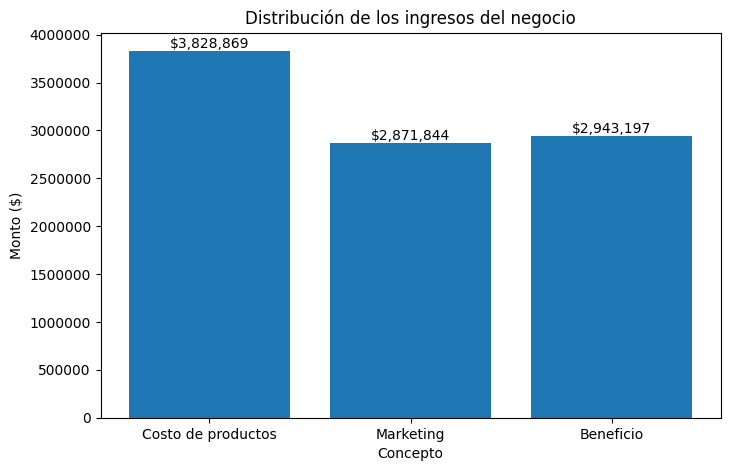

In [ ]:
# Visualizar la distribución de los ingresos

import matplotlib.pyplot as plt

valores = [costo_total, inversion_marketing, beneficio]
categorias = ['Costo de productos', 'Marketing', 'Beneficio']

plt.figure(figsize=(8, 5))
plt.bar(categorias, valores)

plt.title('Distribución de los ingresos del negocio')
plt.ylabel('Monto ($)')
plt.xlabel('Concepto')

plt.ticklabel_format(style='plain', axis='y')

for i, valor in enumerate(valores):
    plt.text(i, valor, f'${valor:,.0f}', ha='center', va='bottom')

plt.show()

La gráfica muestra cómo se distribuyen los ingresos generados por el negocio entre sus principales componentes. El costo de los productos representa el mayor valor, con aproximadamente $3,83 millones, seguido por el beneficio estimado con $2,94 millones y la inversión en marketing con $2,87 millones.

Se observa que, después de cubrir los costos de los productos y la inversión en marketing, el negocio mantiene una parte importante de sus ingresos como beneficio. Este resultado es consistente con el margen de beneficio positivo calculado anteriormente

In [ ]:

# Verificar si cada fila representa un pedido único

total_filas = len(orders)
pedidos_unicos = orders['id_pedido'].nunique()
pedidos_repetidos = orders['id_pedido'].duplicated().sum()

print('Total de filas:', total_filas)
print('Pedidos únicos:', pedidos_unicos)
print('Filas con id_pedido repetido:', pedidos_repetidos)

Total de filas: 24986
Pedidos únicos: 24986
Filas con id_pedido repetido: 0


In [ ]:
# Calcular el ticket promedio por pedido
ticket_promedio = orders['monto_total'].mean()

# Calcular la cantidad promedio de productos por pedido
cantidad_promedio = orders['cantidad'].mean()

print('Ticket promedio por pedido:', round(ticket_promedio, 2))
print(
    'Cantidad promedio de productos por pedido:',
    round(cantidad_promedio, 2)
)

Ticket promedio por pedido: 385.97
Cantidad promedio de productos por pedido: 1.5


**Ticket promedio y cantidad promedio por pedido**

Se confirmó que cada fila representa un pedido único, por lo que los indicadores se calcularon directamente sobre la tabla de ventas, sin necesidad de realizar agrupaciones adicionales.

Durante el periodo analizado:

- El **ticket promedio por pedido fue de $385,97**.
- La **cantidad promedio fue de 1,5 productos por pedido**.

Esto significa que cada pedido generó, en promedio, $385,97 y estuvo compuesto por aproximadamente uno o dos productos. Para calcular la cantidad promedio, pandas excluyó automáticamente los 50 registros que no contaban con información en la variable `cantidad`.

In [ ]:
# Calcular la cantidad vendida por producto
ventas_por_producto = (
    orders.groupby('nombre_producto')['cantidad']
    .sum()
    .sort_values(ascending=False)
)

display(ventas_por_producto)

nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4198.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Producto desconocido      45.0
Name: cantidad, dtype: float64

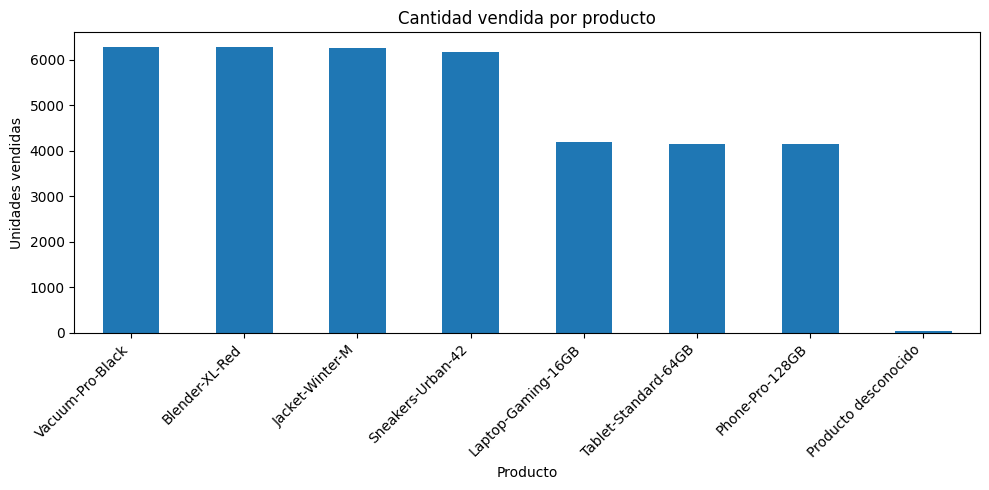

In [ ]:
# Visualizar la cantidad vendida por producto

plt.figure(figsize=(10, 5))

ventas_por_producto.plot(kind='bar')

plt.title('Cantidad vendida por producto')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

El producto con mayor cantidad de unidades vendidas fue Vacuum-Pro-Black, con 6.284 unidades, seguido muy de cerca por Blender-XL-Red con 6.279 unidades, Jacket-Winter-M con 6.256 unidades y Sneakers-Urban-42 con 6.172 unidades.

La gráfica muestra que las ventas se concentran principalmente en estos cuatro productos, aunque no existe un único producto que domine ampliamente sobre los demás. Por otra parte, Producto desconocido presenta únicamente 45 unidades, por lo que su participación es mínima frente al resto del catálogo

In [ ]:
# Calcular el gasto de marketing por canal

gasto_por_canal = (
    marketing.groupby('canal')['gasto']
    .sum()
    .sort_values(ascending=False)
)

display(gasto_por_canal)

canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64

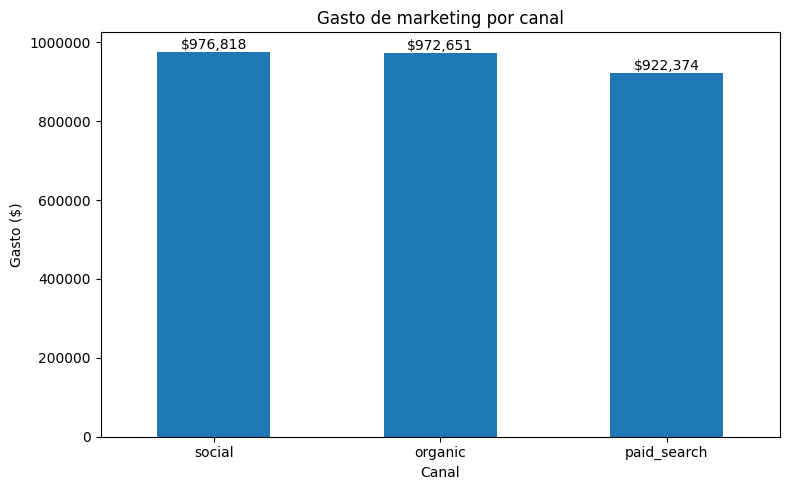

In [ ]:
# Visualizar el gasto de marketing por canal

plt.figure(figsize=(8, 5))

gasto_por_canal.plot(kind='bar')

plt.title('Gasto de marketing por canal')
plt.xlabel('Canal')
plt.ylabel('Gasto ($)')

plt.xticks(rotation=0)

for i, valor in enumerate(gasto_por_canal):
    plt.text(i, valor, f'${valor:,.0f}', ha='center', va='bottom')

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

La inversión en marketing presenta una distribución relativamente equilibrada entre los tres canales analizados. Social registra el mayor gasto con aproximadamente 976,8 mil, seguido muy de cerca por Organic con 972,7 mil, mientras que Paid Search presenta la menor inversión con aproximadamente $922,4 mil.

Las diferencias entre los canales son reducidas, lo que indica que la inversión en marketing se distribuyó de manera similar entre ellos. Sin embargo, estos resultados muestran únicamente el nivel de gasto y no permiten determinar cuál canal fue más efectivo, ya que para ello sería necesario relacionar la inversión con métricas de ventas o conversión.

Evaluación general de los KPIs

Durante el periodo analizado, el negocio generó 9.643.909,56 en ingresos, obteniendo un beneficio estimado de $2.943.197,02 y un margen de 30,52 %, lo que refleja una rentabilidad positiva.

El ticket promedio fue de $385,97 y se vendieron en promedio 1,5 productos por pedido. Vacuum-Pro-Black fue el producto con mayor cantidad de unidades vendidas, aunque los principales productos presentan niveles de venta similares. Por su parte, la inversión en marketing estuvo distribuida de manera relativamente equilibrada entre los tres canales analizados.

En general, los KPIs muestran un desempeño positivo durante el periodo estudiado. El beneficio debe considerarse una estimación, debido a los 80 registros sin costo calculable, cuyo impacto representa aproximadamente el 0,35 % de los ingresos.



<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 sería ideal agregar las gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos.

Pero para complementar esta parte también puedes agregar tu interpretación de las gráficas mostradas en una celda markdown.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre es importante tener un proceso de análisis claro y fácil de entender en todos tus notebooks para que cuando alguien de tu equipo quiera reproducir tu trabajo puedan entenderlo facilmente.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# Revisar la estructura de events

print('Dimensiones:', events.shape)

print('\nColumnas:')
print(events.columns.tolist())

print('\nTipos de datos:')
display(events.dtypes)

print('\nValores ausentes:')
display(events.isna().sum())

Dimensiones: (120000, 8)

Columnas:
['id_usuario', 'id_sesion', 'nombre_evento', 'timestamp_evento', 'pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']

Tipos de datos:


id_usuario            object
id_sesion             object
nombre_evento         object
timestamp_evento      object
pais                  object
dispositivo           object
fuente_referencia     object
categoria_producto    object
dtype: object


Valores ausentes:


id_usuario            0
id_sesion             0
nombre_evento         0
timestamp_evento      0
pais                  0
dispositivo           0
fuente_referencia     0
categoria_producto    0
dtype: int64

In [ ]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''

SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) as usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY usuarios_unicos DESC;
'''
totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH first_visit AS (
    SELECT
        id_usuario,
        MIN(timestamp_evento) AS fecha_first_visit
    FROM events
    WHERE nombre_evento = 'first_visit'
    GROUP BY id_usuario
),

select_item AS (
    SELECT
        e.id_usuario,
        MIN(e.timestamp_evento) AS fecha_select_item
    FROM events e
    INNER JOIN first_visit f
        ON e.id_usuario = f.id_usuario
    WHERE e.nombre_evento = 'select_item'
      AND e.timestamp_evento >= f.fecha_first_visit
    GROUP BY e.id_usuario
),

add_to_cart AS (
    SELECT
        e.id_usuario,
        MIN(e.timestamp_evento) AS fecha_add_to_cart
    FROM events e
    INNER JOIN select_item s
        ON e.id_usuario = s.id_usuario
    WHERE e.nombre_evento = 'add_to_cart'
      AND e.timestamp_evento >= s.fecha_select_item
    GROUP BY e.id_usuario
),

begin_checkout AS (
    SELECT
        e.id_usuario,
        MIN(e.timestamp_evento) AS fecha_begin_checkout
    FROM events e
    INNER JOIN add_to_cart a
        ON e.id_usuario = a.id_usuario
    WHERE e.nombre_evento = 'begin_checkout'
      AND e.timestamp_evento >= a.fecha_add_to_cart
    GROUP BY e.id_usuario
),

add_payment_info AS (
    SELECT
        e.id_usuario,
        MIN(e.timestamp_evento) AS fecha_add_payment_info
    FROM events e
    INNER JOIN begin_checkout b
        ON e.id_usuario = b.id_usuario
    WHERE e.nombre_evento = 'add_payment_info'
      AND e.timestamp_evento >= b.fecha_begin_checkout
    GROUP BY e.id_usuario
),

purchase AS (
    SELECT
        e.id_usuario,
        MIN(e.timestamp_evento) AS fecha_purchase
    FROM events e
    INNER JOIN add_payment_info p
        ON e.id_usuario = p.id_usuario
    WHERE e.nombre_evento = 'purchase'
      AND e.timestamp_evento >= p.fecha_add_payment_info
    GROUP BY e.id_usuario
)

SELECT 'first_visit' AS etapa, COUNT(*) AS usuarios FROM first_visit

UNION ALL
SELECT 'select_item', COUNT(*) FROM select_item

UNION ALL
SELECT 'add_to_cart', COUNT(*) FROM add_to_cart

UNION ALL
SELECT 'begin_checkout', COUNT(*) FROM begin_checkout

UNION ALL
SELECT 'add_payment_info', COUNT(*) FROM add_payment_info

UNION ALL
SELECT 'purchase', COUNT(*) FROM purchase;'''

funnel = pd.read_sql(query_conversion, con=engine)

funnel

,etapa,usuarios
0,first_visit,7796
1,select_item,6728
2,add_to_cart,4983
3,begin_checkout,2663
4,add_payment_info,919
5,purchase,258


In [ ]:
funnel['usuarios_perdidos'] = funnel['usuarios'].shift(1) - funnel['usuarios']

funnel['conversion_etapa'] = (
    funnel['usuarios'] / funnel['usuarios'].shift(1) * 100
).round(2)

funnel['conversion_desde_first_visit'] = (
    funnel['usuarios'] / funnel['usuarios'].iloc[0] * 100
).round(2)

funnel

,etapa,usuarios,usuarios_perdidos,conversion_etapa,conversion_desde_first_visit
0,first_visit,7796,NaN,NaN,100.00
1,select_item,6728,1068.0,86.30,86.30
2,add_to_cart,4983,1745.0,74.06,63.92
3,begin_checkout,2663,2320.0,53.44,34.16
4,add_payment_info,919,1744.0,34.51,11.79
5,purchase,258,661.0,28.07,3.31


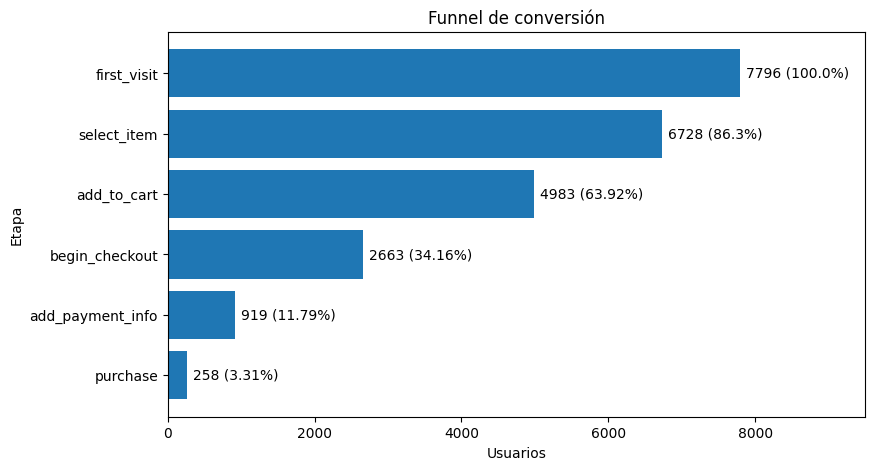

In [ ]:
# Visualizar el funnel de conversión

plt.figure(figsize=(9, 5))

plt.barh(funnel['etapa'], funnel['usuarios'])

plt.title('Funnel de conversión')
plt.xlabel('Usuarios')
plt.ylabel('Etapa')

plt.gca().invert_yaxis()

for i, (usuarios, conversion) in enumerate(
    zip(funnel['usuarios'], funnel['conversion_desde_first_visit'])
):
    plt.text(
        usuarios + 80,
        i,
        f'{usuarios} ({conversion}%)',
        va='center'
    )
plt.xlim(0, 9500)

plt.show()

**Análisis del funnel de conversión**

El funnel inicia con 7.796 usuarios en first_visit. De ellos, el 86,30 % llega a select_item, el 63,92 % alcanza add_to_cart y el 34,16 % llega a begin_checkout. Posteriormente, solo el 11,79 % de los usuarios iniciales registra información de pago y finalmente el 3,31 % completa una compra.

La mayor pérdida en cantidad de usuarios ocurre entre add_to_cart y begin_checkout, donde se pierden 2.320 usuarios. Sin embargo, la menor conversión entre etapas se presenta de add_payment_info a purchase, con una tasa de 28,07 %.

En general, el funnel muestra una disminución progresiva de usuarios a medida que avanzan en el proceso de compra. Los principales puntos de atención se encuentran en las etapas finales, especialmente en el inicio del checkout, el registro de la información de pago y la finalización de la compra.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí te recomendaría agregar el cálculo de la conversión tomando cómo referencia el primer evento para tener la conversión total a partir de ahí, por ejemplo, para sacar la conversión de `select_item` puedes sacarlo tomando como referencia `first_visit`: `# usuarios first_visit / # usuarios select_item`
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Verificar los periodos y valores de actividad

query_validacion_actividad = '''
SELECT
    dias_despues_registro,
    activo,
    COUNT(*) AS cantidad_registros
FROM user_activity
GROUP BY
    dias_despues_registro,
    activo
ORDER BY
    dias_despues_registro,
    activo;
'''

validacion_actividad = pd.read_sql(
    query_validacion_actividad,
    con=engine
)

validacion_actividad

,dias_despues_registro,activo,cantidad_registros
0,7,0,4640
1,7,1,3360
2,14,0,4645
3,14,1,3355
4,21,0,4650
5,21,1,3350
6,28,0,4750
7,28,1,3250


In [ ]:
query_validacion_users = '''
SELECT
    COUNT(*) AS total_registros,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM users;
'''

validacion_users = pd.read_sql(
    query_validacion_users,
    con=engine
)

validacion_users

,total_registros,usuarios_unicos
0,8000,8000


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH usuarios_cohorte AS (
    SELECT
        id_usuario,
        DATE_TRUNC(
            'month',
            CAST(fecha_registro AS DATE)
        )::DATE AS cohorte
    FROM users
),

tamano_cohorte AS (
    SELECT
        cohorte,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales
    FROM usuarios_cohorte
    GROUP BY cohorte
),

usuarios_retenidos AS (
    SELECT
        uc.cohorte,

        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 7
                 AND ua.activo = 1
            THEN uc.id_usuario
        END) AS retenido_w1,

        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 14
                 AND ua.activo = 1
            THEN uc.id_usuario
        END) AS retenido_w2,

        COUNT(DISTINCT CASE
            WHEN ua.dias_despues_registro = 21
                 AND ua.activo = 1
            THEN uc.id_usuario
        END) AS retenido_w3

    FROM usuarios_cohorte AS uc
    LEFT JOIN user_activity AS ua
        ON uc.id_usuario = ua.id_usuario
    GROUP BY uc.cohorte
)

SELECT
    tc.cohorte,
    tc.usuarios_iniciales,
    ur.retenido_w1,
    ur.retenido_w2,
    ur.retenido_w3,

    ROUND(
        ur.retenido_w1 * 100.0
        / tc.usuarios_iniciales,
        2
    ) AS semana_1,

    ROUND(
        ur.retenido_w2 * 100.0
        / tc.usuarios_iniciales,
        2
    ) AS semana_2,

    ROUND(
        ur.retenido_w3 * 100.0
        / tc.usuarios_iniciales,
        2
    ) AS semana_3

FROM tamano_cohorte AS tc
JOIN usuarios_retenidos AS ur
    ON tc.cohorte = ur.cohorte
ORDER BY tc.cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01,1687,695,676,706,41.20,40.07,41.85


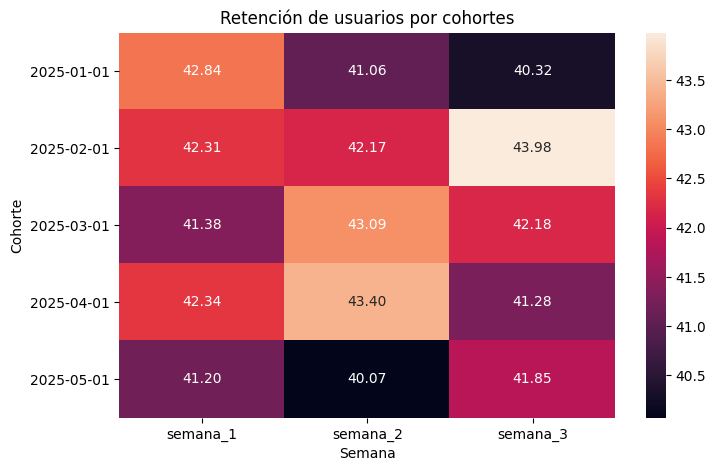

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cohorte_final[['semana_1', 'semana_2', 'semana_3']],
    annot=True,
    fmt='.2f',
    yticklabels=cohorte_final['cohorte']
)

plt.title('Retención de usuarios por cohortes')
plt.xlabel('Semana')
plt.ylabel('Cohorte')

plt.show()

**Análisis de retención por cohortes**

Se construyeron cohortes mensuales a partir del mes de registro de los 8.000 usuarios y se evaluó su actividad durante las semanas 1, 2 y 3 posteriores al registro.

La retención se mantiene relativamente estable alrededor del 42 % en todas las cohortes y semanas analizadas. En la primera semana, los porcentajes se encuentran entre el 41,20 % y el 42,84 %; en la segunda, entre el 40,07 % y el 43,40 %; y en la tercera, entre el 40,32 % y el 43,98 %.

No se observa una disminución progresiva uniforme de la retención. Algunas cohortes incluso presentan incrementos en semanas posteriores. Esto ocurre porque cada semana se evalúa de forma independiente: un usuario puede estar inactivo durante una semana y regresar en la siguiente.

La cohorte de enero obtuvo la mayor retención en la semana 1, con un 42,84 %. En la semana 2 se destacó la cohorte de abril, con un 43,40 %, mientras que la cohorte de febrero presentó el mejor resultado de la semana 3, con un 43,98 %.

En términos generales, aproximadamente el 42 % de los usuarios regresa y permanece activo en cada semana evaluada, mientras que cerca del 58 % no registra actividad en cada punto de medición. Por ello, existe una oportunidad importante para fortalecer las estrategias de activación y reenganche durante las primeras semanas posteriores al registro.

Estos resultados no permiten afirmar que los usuarios inactivos hayan abandonado definitivamente la plataforma, debido a que pueden regresar en periodos posteriores.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La query está muy bien y estás obteniendo resultados adecuados pero lo complementarías mejor si agregaras una visualización.
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  


Hipótesis estadística
   - **H₀ (Hipótesis nula):** ...
   - **H₁ (Hipótesis alternativa):** ...
   
**Test estadístico:** ...  
**Nivel de significancia alpha:** ...

In [ ]:


# Cargar el dataset del experimento A/B

url_experimento = (
    'https://practicum-content.s3.amazonaws.com/'
    'datasets/experiment_checkout_ui.csv'


)

experiment = pd.read_csv(url_experimento)

# Explorar el dataset
display(experiment.head())

print('Dimensiones:', experiment.shape)

print('\nColumnas:')
print(experiment.columns.tolist())

print('\nTipos de datos:')
display(experiment.dtypes)

print('\nValores ausentes:')
display(experiment.isna().sum())



,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


Dimensiones: (10000, 7)

Columnas:
['id_usuario', 'variante', 'convirtio', 'dispositivo', 'pais', 'duracion_sesion', 'timestamp']

Tipos de datos:


id_usuario          object
variante            object
convirtio            int64
dispositivo         object
pais                object
duracion_sesion    float64
timestamp           object
dtype: object


Valores ausentes:


id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64

In [ ]:
# Convertir timestamp al tipo fecha
experiment['timestamp'] = pd.to_datetime(
    experiment['timestamp'],
    errors='coerce'
)

# Verificar usuarios duplicados
total_registros = len(experiment)
usuarios_unicos = experiment['id_usuario'].nunique()
usuarios_duplicados = experiment['id_usuario'].duplicated().sum()

print('Total de registros:', total_registros)
print('Usuarios únicos:', usuarios_unicos)
print('Usuarios duplicados:', usuarios_duplicados)

# Verificar categorías y distribución de los grupos
print('\nValores de variante:')
display(experiment['variante'].value_counts())

print('\nValores de conversión:')
display(experiment['convirtio'].value_counts())

print('\nDistribución por variante y conversión:')
display(
    pd.crosstab(
        experiment['variante'],
        experiment['convirtio']
    )
)

# Revisar el periodo del experimento
print('\nInicio del experimento:', experiment['timestamp'].min())
print('Fin del experimento:', experiment['timestamp'].max())

# Comprobar si la conversión generó fechas ausentes
print(
    'Fechas inválidas después de la conversión:',
    experiment['timestamp'].isna().sum()
)

Total de registros: 10000
Usuarios únicos: 10000
Usuarios duplicados: 0

Valores de variante:


tratamiento    5035
control        4965
Name: variante, dtype: int64


Valores de conversión:


0    8401
1    1599
Name: convirtio, dtype: int64


Distribución por variante y conversión:


convirtio,0,1
variante,,
control,4186,779
tratamiento,4215,820



Inicio del experimento: 2025-01-01 00:00:00
Fin del experimento: 2025-06-30 00:00:00
Fechas inválidas después de la conversión: 0


In [ ]:
# Resumir los resultados por variante

resumen_conversion = (
    experiment
    .groupby('variante')['convirtio']
    .agg(
        usuarios='count',
        conversiones='sum',
        tasa_conversion='mean'
    )
    .reset_index()
)

# Convertir la tasa a porcentaje
resumen_conversion['tasa_conversion'] = (
    resumen_conversion['tasa_conversion'] * 100
).round(2)

display(resumen_conversion)

# Obtener las tasas de cada grupo
tasa_control = (
    experiment.loc[
        experiment['variante'] == 'control',
        'convirtio'
    ].mean() * 100
)

tasa_tratamiento = (
    experiment.loc[
        experiment['variante'] == 'tratamiento',
        'convirtio'
    ].mean() * 100
)

# Calcular la diferencia en puntos porcentuales
diferencia_pp = tasa_tratamiento - tasa_control

# Calcular el cambio relativo frente al control
mejora_relativa = (
    diferencia_pp / tasa_control * 100
)

print('Tasa del grupo control:', round(tasa_control, 2), '%')
print(
    'Tasa del grupo tratamiento:',
    round(tasa_tratamiento, 2),
    '%'
)
print(
    'Diferencia:',
    round(diferencia_pp, 2),
    'puntos porcentuales'
)
print(
    'Cambio relativo:',
    round(mejora_relativa, 2),
    '%'
)

,variante,usuarios,conversiones,tasa_conversion
0,control,4965,779,15.69
1,tratamiento,5035,820,16.29


Tasa del grupo control: 15.69 %
Tasa del grupo tratamiento: 16.29 %
Diferencia: 0.6 puntos porcentuales
Cambio relativo: 3.8 %


In [ ]:
# Importar la prueba Z para dos proporciones

from statsmodels.stats.proportion import proportions_ztest

# Usar el resumen calculado previamente
resumen_test = resumen_conversion.set_index('variante')

# Preparar los datos en orden: control y tratamiento
conteos = [
    resumen_test.at['control', 'conversiones'],
    resumen_test.at['tratamiento', 'conversiones']
]

num_observaciones = [
    resumen_test.at['control', 'usuarios'],
    resumen_test.at['tratamiento', 'usuarios']
]

alpha = 0.05

# Aplicar la prueba Z bilateral
estadistico_z, p_valor = proportions_ztest(
    count=conteos,
    nobs=num_observaciones,
    alternative='two-sided'
)

print('Conversiones:', conteos)
print('Total de usuarios:', num_observaciones)
print('Estadístico Z:', round(estadistico_z, 4))
print('Valor p:', round(p_valor, 4))

if p_valor < alpha:
    print(
        'Se rechaza la hipótesis nula: existe una diferencia '
        'estadísticamente significativa.'
    )
else:
    print(
        'No se rechaza la hipótesis nula: no existe evidencia '
        'suficiente de una diferencia estadísticamente significativa.'
    )

Conversiones: [779, 820]
Total de usuarios: [4965, 5035]
Estadístico Z: -0.8133
Valor p: 0.4161
No se rechaza la hipótesis nula: no existe evidencia suficiente de una diferencia estadísticamente significativa.


**Resultado del experimento A/B**

Se evaluó el impacto de la nueva interfaz del checkout mediante una prueba Z bilateral para dos proporciones independientes, utilizando un nivel de significancia de 0,05.

Las hipótesis planteadas fueron:

- **H₀ (hipótesis nula):** la tasa de conversión del grupo de control es igual a la del grupo de tratamiento. El cambio en la interfaz no produjo un impacto estadísticamente significativo.
- **H₁ (hipótesis alternativa):** la tasa de conversión del grupo de control es diferente a la del grupo de tratamiento. El cambio en la interfaz produjo un impacto estadísticamente significativo.

El grupo de control registró 779 conversiones entre 4.965 usuarios, alcanzando una tasa de conversión del 15,69 %. El grupo de tratamiento obtuvo 820 conversiones entre 5.035 usuarios, con una tasa del 16,29 %.

La variante de tratamiento presentó una mejora observada de 0,60 puntos porcentuales, equivalente a un incremento relativo del 3,8 % frente al grupo de control.

La prueba estadística produjo un estadístico Z de -0,8133 y un valor p de 0,4161. Debido a que el valor p es mayor que el nivel de significancia de 0,05, no se rechaza la hipótesis nula.

Por tanto, aunque la nueva interfaz obtuvo una tasa de conversión ligeramente superior, no existe evidencia estadística suficiente para afirmar que la diferencia haya sido causada por el cambio implementado y no por la variabilidad aleatoria.

### Recomendación

No se recomienda implementar la nueva interfaz de forma general basándose únicamente en este resultado. Se sugiere mantener el experimento durante más tiempo o aumentar el tamaño de la muestra para obtener mayor capacidad de detectar una diferencia pequeña.

También podría analizarse el resultado por dispositivo y país para identificar si el tratamiento genera un impacto relevante en algún segmento específico. Estos análisis deberían considerarse exploratorios y validarse posteriormente con nuevos experimentos.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

**Conclusiones y recomendaciones generales**

El análisis realizado permitió evaluar el desempeño de Rappy desde diferentes perspectivas: rentabilidad, comportamiento de ventas, conversión de usuarios, retención y resultados del experimento A/B.

Hallazgos principales

Durante el período analizado, el negocio generó ingresos por aproximadamente $9,64 millones, con un beneficio estimado de $2,94 millones y un margen cercano al 30,52 %, lo que muestra un resultado positivo en términos de rentabilidad. El ticket promedio fue de $385,97 y cada pedido incluyó aproximadamente 1,5 productos.

En el proceso de conversión se identificó una oportunidad importante. De los 7.796 usuarios que iniciaron el funnel en first_visit, únicamente 258 completaron purchase, equivalente al 3,31 %. La mayor pérdida en número de usuarios se presenta entre add_to_cart y begin_checkout, mientras que las etapas finales también muestran bajas tasas de avance, por lo que el proceso de checkout representa uno de los principales puntos de mejora.

La retención se mantiene relativamente estable alrededor del 40–44 % durante las tres primeras semanas analizadas. Aunque no se observa una caída progresiva uniforme entre las cohortes, aproximadamente seis de cada diez usuarios no presentan actividad en cada punto de medición, evidenciando una oportunidad para fortalecer las estrategias de reactivación y fidelización.

Por otra parte, la prueba A/B mostró una conversión de 15,69 % en el grupo de control y 16,29 % en el tratamiento. Aunque la nueva interfaz presentó una mejora observada de 0,60 puntos porcentuales, el resultado no fue estadísticamente significativo (p = 0,4161), por lo que no existe evidencia suficiente para atribuir la diferencia al cambio implementado.

**Oportunidades de mejora y recomendaciones**

A partir de estos resultados, se recomienda priorizar la optimización del proceso de compra, especialmente desde el carrito hasta la finalización del pago, identificando posibles puntos de fricción que expliquen el abandono de usuarios.

También sería conveniente relacionar la inversión en marketing con métricas de adquisición, conversión e ingresos por canal. Actualmente se conoce cuánto se invierte en cada canal, pero no cuál genera el mejor retorno, por lo que incorporar métricas como ROAS o costo de adquisición permitiría orientar mejor el presupuesto.

En retención, se recomienda desarrollar acciones de reactivación durante las primeras semanas posteriores al registro y analizar el comportamiento por segmentos como país, dispositivo o tipo de usuario para identificar grupos con mayor riesgo de abandono.

Finalmente, no se recomienda implementar de forma general la nueva interfaz basándose únicamente en el experimento actual. Sería conveniente ampliar el período o tamaño de la muestra y continuar evaluando el tratamiento. Los análisis por dispositivo o país pueden utilizarse de manera exploratoria para generar nuevas hipótesis que posteriormente deberían validarse mediante nuevos experimentos.

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [ ]:
# (Pega aquí tu link)
# link de power bi o tableau
# link de one drive / google drive

In [ ]:
https://drive.google.com/drive/folders/1MSoragRTSQbcfT092vxfkMHjOAuILNZo?usp=drive_link

SyntaxError: invalid syntax (3016705254.py, line 1)

<div class="alert alert-block alert-danger">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Victor. Hay algunos puntos con oportunidades de mejora donde te he dejado algunos comentarios.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Victor!**

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>